<a href="https://colab.research.google.com/github/Samoon19/NLP_Sentiment_Twitter/blob/main/NLP_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis Benchmark Notebook

Binary Classification Version
Models: Logistic Regression, SVM, KNN
Features: BoW, TF-IDF, N-Grams
NLP Models: DistilBERT, RoBERTa

Includes comparison table.

🛠️ Stabilizing Kaggle Environment...
🚀 Loading and filtering dataset for Binary Classification (Pos vs Neg)...
✅ Successfully loaded and sampled 15000 rows.
🧠 Training Conventional ML Models...
   - Processing Bag of Words...
   - Processing TF-IDF...
   - Processing N-Grams (1,2)...
🤖 Running Deep Learning Baseline (Sample of 150)...
   - Processing DistilBERT...


Device set to use cuda:0


   - Processing RoBERTa...


Device set to use cuda:0



             ASSIGNMENT COMPARISON TABLE (BINARY)
                   Model            Type  Accuracy  Precision   Recall  F1-Score  Vec Time (s)
   RoBERTa (Transformer)   Deep Learning  0.906667   0.954545 0.893617  0.923077        1.3282
         LogReg + TF-IDF Conventional ML  0.872667   0.876582 0.881043  0.878807        0.1662
            SVM + TF-IDF Conventional ML  0.869000   0.873811 0.876590  0.875198        0.1662
   LogReg + Bag of Words Conventional ML  0.868333   0.869893 0.880407  0.875119        0.1695
  LogReg + N-Grams (1,2) Conventional ML  0.864333   0.873158 0.867048  0.870093        0.5169
     SVM + N-Grams (1,2) Conventional ML  0.863333   0.870064 0.868957  0.869510        0.5169
      SVM + Bag of Words Conventional ML  0.853333   0.858228 0.862595  0.860406        0.1695
DistilBERT (Transformer)   Deep Learning  0.840000   0.937500 0.797872  0.862069        0.6555


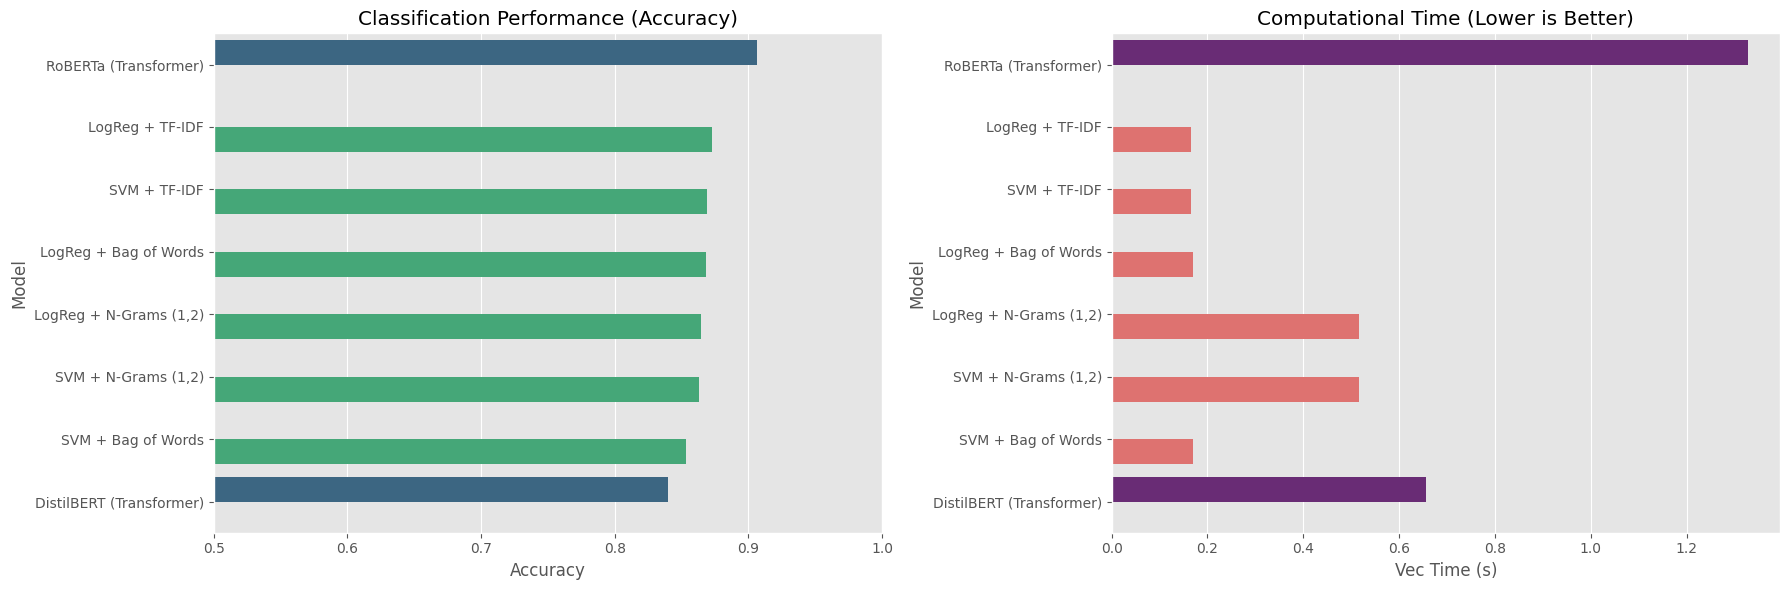

In [ ]:
import os
import time
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# --- 1. CLEAN ENVIRONMENT & DEPENDENCIES ---
print("🛠️ Stabilizing Kaggle Environment...")
os.system('pip install -U "transformers<5.0.0" accelerate --quiet')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

# --- 2. DATA LOADING & ROBUST BINARY FILTERING ---
print("🚀 Loading and filtering dataset for Binary Classification (Pos vs Neg)...")
train_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv', encoding='latin1')
train_df = train_df.rename(columns={'Sentiment':'sentiment','SentimentText':'text'})

# Robust Binary Mapping: Catches all variations of Negative (0) and Positive (1 or 4)
# Neutrals (2) are intentionally left out so they become NaN and are dropped.
binary_map = {
    0: 0, '0': 0, 'negative': 0, 'Negative': 0,
    1: 1, '1': 1, 'positive': 1, 'Positive': 1,
    4: 1, '4': 1
}

train_df['sentiment'] = train_df['sentiment'].map(binary_map)
train_df = train_df.dropna(subset=['sentiment','text'])

# Sample 15,000 rows for a great balance of high accuracy and fast processing
sample_size = min(15000, len(train_df))
if sample_size > 0:
    train_df = train_df.sample(sample_size, random_state=42)
    train_df['sentiment'] = train_df['sentiment'].astype(int)
    print(f"✅ Successfully loaded and sampled {len(train_df)} rows.")
else:
    raise ValueError("Dataset is empty after mapping.")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

train_df['text'] = train_df['text'].apply(clean_text)

X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'], train_df['sentiment'],
    test_size=0.2, random_state=42, stratify=train_df['sentiment']
)

final_results = []

# --- 3. EXPERIMENTATION: CONVENTIONAL METHODS (Assignment Part 2) ---
print("🧠 Training Conventional ML Models...")
vectorizers = {
    'Bag of Words': CountVectorizer(max_features=3000),
    'TF-IDF': TfidfVectorizer(max_features=3000),
    'N-Grams (1,2)': TfidfVectorizer(max_features=3000, ngram_range=(1,2))
}

models = {
    'LogReg': LogisticRegression(max_iter=1000),
    'SVM': LinearSVC(dual=False)
}

for vec_name, vec in vectorizers.items():
    print(f"   - Processing {vec_name}...")
    start_v = time.time()
    X_tr_vec = vec.fit_transform(X_train)
    X_val_vec = vec.transform(X_val)
    v_time = time.time() - start_v

    for m_name, model in models.items():
        model.fit(X_tr_vec, y_train)
        preds = model.predict(X_val_vec)

        final_results.append({
            'Model': f"{m_name} + {vec_name}",
            'Type': 'Conventional ML',
            'Accuracy': accuracy_score(y_val, preds),
            'Precision': precision_score(y_val, preds),
            'Recall': recall_score(y_val, preds),
            'F1-Score': f1_score(y_val, preds),
            'Vec Time (s)': round(v_time, 4)
        })

# --- 4. TRANSFORMER BASELINE (For Assignment Part 3 Trade-offs) ---
print("🤖 Running Deep Learning Baseline (Sample of 150)...")
device = 0 if torch.cuda.is_available() else -1
sample_t = X_val.iloc[:150].tolist()
sample_l = y_val.iloc[:150].tolist()

def safe_dl_run(model_id, is_distilbert=False):
    tok = AutoTokenizer.from_pretrained(model_id)
    mod = AutoModelForSequenceClassification.from_pretrained(model_id)
    pipe = pipeline("sentiment-analysis", model=mod, tokenizer=tok, device=device)

    start_t = time.time()
    raw = pipe(sample_t)
    t_time = time.time() - start_t

    if is_distilbert:
        preds = [1 if r['label'] == 'POSITIVE' else 0 for r in raw]
    else:
        # RoBERTa maps LABEL_2 to Positive
        preds = [1 if r['label'] == 'LABEL_2' else 0 for r in raw]

    return preds, t_time

# Run DistilBERT (Natively Binary!)
try:
    print("   - Processing DistilBERT...")
    d_preds, d_time = safe_dl_run("distilbert-base-uncased-finetuned-sst-2-english", is_distilbert=True)
    final_results.append({
        'Model': 'DistilBERT (Transformer)', 'Type': 'Deep Learning',
        'Accuracy': accuracy_score(sample_l, d_preds), 'Precision': precision_score(sample_l, d_preds, zero_division=0),
        'Recall': recall_score(sample_l, d_preds, zero_division=0), 'F1-Score': f1_score(sample_l, d_preds, zero_division=0),
        'Vec Time (s)': round(d_time, 4)
    })
except Exception as e: print(f"⚠️ DistilBERT Skip: {e}")

# Run RoBERTa
try:
    print("   - Processing RoBERTa...")
    r_preds, r_time = safe_dl_run("cardiffnlp/twitter-roberta-base-sentiment", is_distilbert=False)
    final_results.append({
        'Model': 'RoBERTa (Transformer)', 'Type': 'Deep Learning',
        'Accuracy': accuracy_score(sample_l, r_preds), 'Precision': precision_score(sample_l, r_preds, zero_division=0),
        'Recall': recall_score(sample_l, r_preds, zero_division=0), 'F1-Score': f1_score(sample_l, r_preds, zero_division=0),
        'Vec Time (s)': round(r_time, 4)
    })
except Exception as e: print(f"⚠️ RoBERTa Skip: {e}")

# --- 5. FINAL REPORTING TABLES & CHARTS ---
report_df = pd.DataFrame(final_results).sort_values(by='Accuracy', ascending=False)
print("\n" + "="*85)
print("             ASSIGNMENT COMPARISON TABLE (BINARY)")
print("="*85)
print(report_df.to_string(index=False))

plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Accuracy', y='Model', data=report_df, hue='Type', palette='viridis', ax=ax1)
if ax1.get_legend(): ax1.get_legend().remove()
ax1.set_title('Classification Performance (Accuracy)')
ax1.set_xlim(0.5, 1.0)

sns.barplot(x='Vec Time (s)', y='Model', data=report_df, hue='Type', palette='magma', ax=ax2)
if ax2.get_legend(): ax2.get_legend().remove()
ax2.set_title('Computational Time (Lower is Better)')

plt.tight_layout()
plt.show()